In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('college_student_placement_dataset (1).csv')

In [4]:
dataset

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [5]:
dataset.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [7]:
dataset['Placement'].unique()

array(['No', 'Yes'], dtype=object)

In [8]:
dataset['Placement'].nunique()

2

In [11]:
dataset['Placement'].count()

10000

In [12]:
dataset['Placement'].value_counts()

Placement
No     8341
Yes    1659
Name: count, dtype: int64

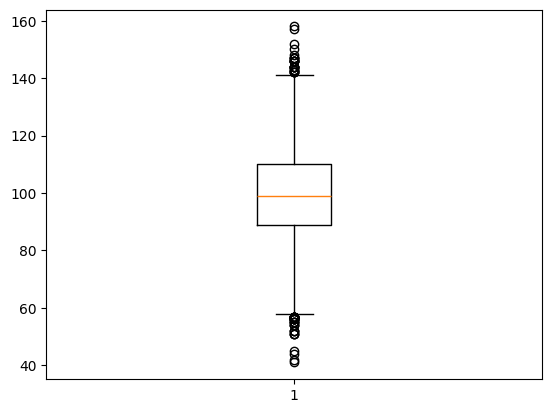

In [13]:
plt.boxplot(dataset['IQ'])
plt.show()

In [15]:
q1 = dataset['IQ'].quantile(0.25)

In [17]:
q3 = dataset['IQ'].quantile(0.75)

In [18]:
IQR = q3-q1
IQR

21.0

### Encoding

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset["Internship_Experience"] = le.fit_transform (dataset["Internship_Experience"])

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset["College_ID"] = le.fit_transform (dataset["College_ID"])

### Divide X & Y

In [22]:
X = dataset[["College_ID","IQ","Prev_Sem_Result","CGPA","Academic_Performance","Internship_Experience","Extra_Curricular_Score","Communication_Skills","Projects_Completed"]]

In [23]:
y = dataset["Placement"]

### split Data Training & Testing

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=40)

### Using cross validation

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate

In [26]:
knn = KNeighborsClassifier(n_neighbors=7, metric="euclidean")
result = cross_validate(knn, X_train,y_train, cv=5, return_train_score=True)
result

{'fit_time': array([0.01498508, 0.00900102, 0.00902915, 0.01000214, 0.0085063 ]),
 'score_time': array([0.07097316, 0.04641223, 0.04640341, 0.04825306, 0.04854846]),
 'test_score': array([0.87428571, 0.88142857, 0.88642857, 0.88142857, 0.87714286]),
 'train_score': array([0.92125   , 0.91482143, 0.91625   , 0.91464286, 0.91875   ])}

In [27]:
result["train_score"]

array([0.92125   , 0.91482143, 0.91625   , 0.91464286, 0.91875   ])

In [28]:
print("Avg Training acc after cross validation",result["train_score"].mean())

Avg Training acc after cross validation 0.917142857142857
